## 1. Import Necessary Libraries

In [41]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

## 2. Import Dataset

In [42]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [4]:
claimants_data.shape

(1340, 7)

In [5]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [6]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

### 4.1 Data Cleaning

In [43]:
claimants_data.dropna(inplace = True)

In [9]:
1340-1096

244

In [12]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [14]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

## 4.2 Seperate your inputs and Outputs

In [44]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"],axis = 1,)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [45]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20,shuffle=True, random_state=34,)

In [77]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


In [84]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
627,1.0,1.0,0.0,40.0,6.337
1125,1.0,1.0,0.0,37.0,4.609
1124,1.0,1.0,0.0,46.0,0.730
1025,1.0,1.0,0.0,38.0,3.406
481,1.0,1.0,0.0,70.0,0.566
...,...,...,...,...,...
658,0.0,1.0,0.0,14.0,4.479
1257,0.0,1.0,0.0,7.0,0.453
1015,1.0,0.0,0.0,69.0,3.110
1114,1.0,1.0,0.0,0.0,7.169


In [19]:
logistic_model = LogisticRegression()

## 6. Model Training

In [47]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [49]:
dt_model = DecisionTreeClassifier(criterion='entropy',max_depth=7)

### Grid Search CV(Cross Validation)


grid search cv simple meaning
Think of GridSearchCV as a smart way to find the best settings (hyperparameters) for your machine learning model.

🔑 Simple Meaning
- A model has hyperparameters (like tree depth in Decision Trees, number of neighbors in KNN, etc.).

- Instead of guessing them, GridSearchCV tries all possible combinations from a grid (list) of values you provide.

- It trains and tests the model for each combination using cross-validation (splitting data into train/test multiple times).

- Finally, it tells you which combination gives the best performance.

🧩 Example
Suppose you have a Decision Tree and want to tune:

max_depth = [3, 5, 7]

min_samples_split = [2, 4]

GridSearchCV will test:

(depth=3, split=2), (depth=3, split=4)

(depth=5, split=2), (depth=5, split=4)

(depth=7, split=2), (depth=7, split=4)

It evaluates each using cross-validation and picks the best.

✅ In short
GridSearchCV = “automatic trial-and-error” for hyperparameters, with cross-validation to ensure reliable results.



In [50]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator  = dt_model,param_grid = {"max_depth":[5,6,7,8,9,10],
                                                                "criterion":['gini','entropy']})
grid_search.fit(X,y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5}
0.7244375259443754


In [51]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator  = dt_model,param_grid = {"max_depth":[5,6,7,8,9,10],
                                                                "criterion":['gini','entropy']})
grid_search.fit(X_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5}
0.7157532467532468


In [52]:
dt_model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


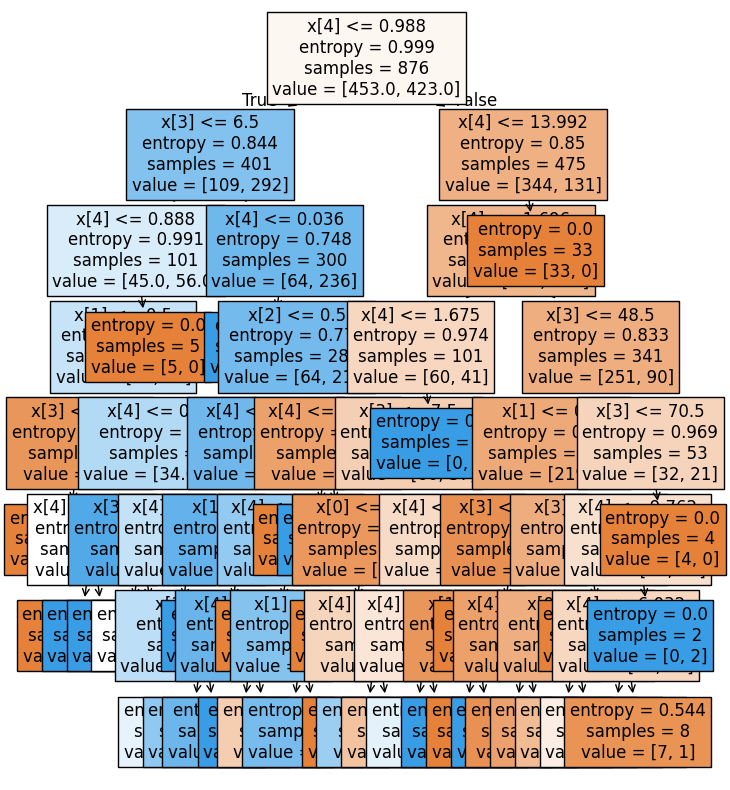

In [53]:
plt.figure( figsize = (8, 10),)
plot_tree(decision_tree = dt_model,fontsize=12,filled=True)
plt.show()

## 7. Model Testing

### Training Data

In [57]:
y_pred_train = dt_model.predict(X_train)
y_pred_train

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,

### Test Data

In [58]:
y_pred_test = dt_model.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

## 8. Model Evaluation

In [60]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### 8.1 Training Data's Evaluation Metrics

In [68]:
accuracy_score(y_train, y_pred_train)

0.7671232876712328

478    0
387    0
47     0
220    0
152    0
      ..
731    0
817    0
557    0
386   -1
599    0
Name: ATTORNEY, Length: 876, dtype: int64

In [61]:
print(confusion_matrix(y_train, y_pred_train))

[[352 101]
 [103 320]]


In [62]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78       453
           1       0.76      0.76      0.76       423

    accuracy                           0.77       876
   macro avg       0.77      0.77      0.77       876
weighted avg       0.77      0.77      0.77       876



### ROC Curve - Receiver Operating Characteristics

##### AUC - Area Under this Curve

0.7667715623189767


Text(0, 0.5, 'True Positive Rate')

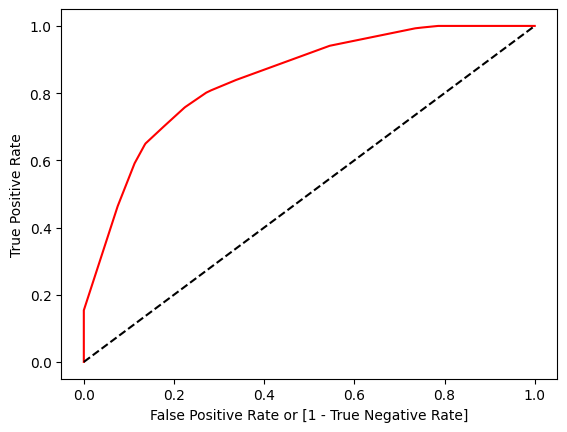

In [63]:
fpr, tpr, thresholds = roc_curve(y_train, dt_model.predict_proba (X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

#### Important
When there is Hign bias , low variance , it was overfitting. So, to generalize max-depth given as 5, earlier max-depth was none in decision tree, after giving deppth
5 now when we we comapre train data vs test data it is low bias , low variance , so the model got Generalized

### 8.2 Test Data's Evaluation Metrics

In [64]:
accuracy_score(y_test, y_pred_test)

0.7272727272727273

In [65]:
print(confusion_matrix(y_test, y_pred_test))

[[93 32]
 [28 67]]


In [66]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       125
           1       0.68      0.71      0.69        95

    accuracy                           0.73       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.73      0.73      0.73       220



0.7246315789473684


Text(0, 0.5, 'True Positive Rate')

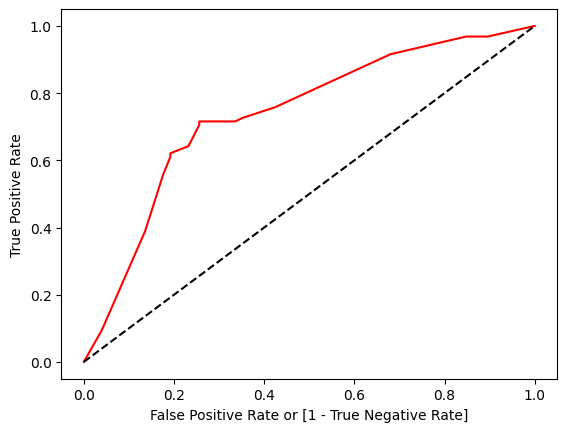

In [67]:
fpr, tpr, thresholds = roc_curve(y_test, dt_model.predict_proba (X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## BIAS - VARIANCE

* Training Error/Accuracy - Bias
* Test Error/Accuracy - Variance.

### Model Overfitting - Less Bias and High Variance.
### Model Underfitting - High Bias and Less Variance.

### EXPECTED MODEL -- GENERALIZED MODEL - Less Bias and Less Variance.

So, there is always a **Tradeoff maintaned between Bias and Variance.**

## 9. Model Deployment

In [39]:
from pickle import dump

In [40]:
dump(logistic_model,open("claimaints.pkl","wb"))

## THE END!!

#### Understanding BIAS- Variance

In [33]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Dummy dataset
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([1.2,2.1,2.9,4.2,5.1,6.0,7.1,8.2,9.1,10.2])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Mean values
print("Train Mean Actual:", np.mean(y_train))
print("Train Mean Predicted:", np.mean(y_train_pred))
print("Test Mean Actual:", np.mean(y_test))
print("Test Mean Predicted:", np.mean(y_test_pred))

# Errors
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))


Train Mean Actual: 5.557142857142857
Train Mean Predicted: 5.557142857142856
Test Mean Actual: 5.733333333333333
Test Mean Predicted: 5.797772277227722
Train MSE: 0.009678217821782189
Test MSE: 0.0075425816096460286


🔎 Interpretation
- If Train Mean ≈ Train Predicted Mean and Test Mean ≈ Test Predicted Mean,
→ the model has low bias (it captures the true average trend).

- If Train MSE is very low but Test MSE is much higher,
→ the model has high variance (overfitting).

- If both errors are reasonably close and means align,
→ the model is generalized (low bias + low variance).

✅ In short:

Underfitting → Both train & test errors high.

Overfitting → Train error low, test error high.

Generalized → Both errors low and means align closely.